# Multi-Tag Emoji Classification and Emotional Analysis
### Using Machine Learning Techniques
**Dataset:** SemEval-2018 Task 1 (E-c: Emotions in Context)  
**Methods:** B-PMI, VADER, TextBlob


In [1]:
# Install required libraries if not already installed
# !pip install pandas numpy nltk vaderSentiment textblob flask scikit-learn matplotlib seaborn emoji gensim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import re
import string
import emoji
import warnings
warnings.filterwarnings('ignore')

# NLTK downloads
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("All libraries loaded successfully!")


All libraries loaded successfully!


## 1. Data Loading

 — SemEval-2018 Task 1 Dataset

In [17]:
EMOTION_COLS = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "love", "optimism", "pessimism",
    "sadness", "surprise", "trust"
]

def load_semeval(split="train"):
    fname_map = {
        "train": "2018-E-c-En-train.txt",
        "dev":   "2018-E-c-En-dev.txt",
        "test":  "2018-E-c-En-test-gold.txt",
    }
    path = os.path.join("data", fname_map[split])
    df = pd.read_csv(path, sep="\t", quoting=3)
    df.columns = [c.strip() for c in df.columns]
    for col in EMOTION_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
    return df

df = load_semeval("train")
print(f"Shape: {df.shape}")
df


Shape: (6838, 13)


,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-En-21441,“Worry is a down payment on a problem you may ...,0,1,0,0,0,0,1,0,0,0,1
1,2017-En-31535,Whatever you decide to do make sure it makes y...,0,0,0,0,1,1,1,0,0,0,0
2,2017-En-21068,@Max_Kellerman it also helps that the majorit...,1,0,1,0,1,0,1,0,0,0,0
3,2017-En-31436,Accept the challenges so that you can literall...,0,0,0,0,1,0,1,0,0,0,0
4,2017-En-22195,My roommate: it's okay that we can't spell bec...,1,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6833,2017-En-21383,@nicky57672 Hi! We are working towards your hi...,0,0,0,0,0,0,0,0,0,0,0
6834,2017-En-41441,@andreamitchell said @berniesanders not only d...,0,1,0,0,0,0,0,0,0,1,0
6835,2017-En-10886,@isthataspider @dhodgs i will fight this guy! ...,1,0,1,0,0,0,0,1,0,0,0
6836,2017-En-40662,i wonder how a guy can broke his penis while h...,0,0,0,0,0,0,0,0,0,1,0


Dataset with Associated Tweet Labels

In [18]:
def build_label_column(df):
    def _labels(row):
        active = [e.capitalize() for e in EMOTION_COLS if row.get(e, 0) == 1]
        return ",".join(active) if active else "None"
    df = df.copy()
    df["Tweet Label"] = df.apply(_labels, axis=1)
    return df[["ID", "Tweet", "Tweet Label"]]
df_label = build_label_column(df)
print(f"Shape: {df_label.shape}")
df_label


Shape: (6838, 3)


,ID,Tweet,Tweet Label
0,2017-En-21441,“Worry is a down payment on a problem you may ...,"Anticipation,Optimism,Trust"
1,2017-En-31535,Whatever you decide to do make sure it makes y...,"Joy,Love,Optimism"
2,2017-En-21068,@Max_Kellerman it also helps that the majorit...,"Anger,Disgust,Joy,Optimism"
3,2017-En-31436,Accept the challenges so that you can literall...,"Joy,Optimism"
4,2017-En-22195,My roommate: it's okay that we can't spell bec...,"Anger,Disgust"
...,...,...,...
6833,2017-En-21383,@nicky57672 Hi! We are working towards your hi...,None
6834,2017-En-41441,@andreamitchell said @berniesanders not only d...,"Anticipation,Surprise"
6835,2017-En-10886,@isthataspider @dhodgs i will fight this guy! ...,"Anger,Disgust,Pessimism"
6836,2017-En-40662,i wonder how a guy can broke his penis while h...,Surprise


##  Bar Graphs on the Dataset

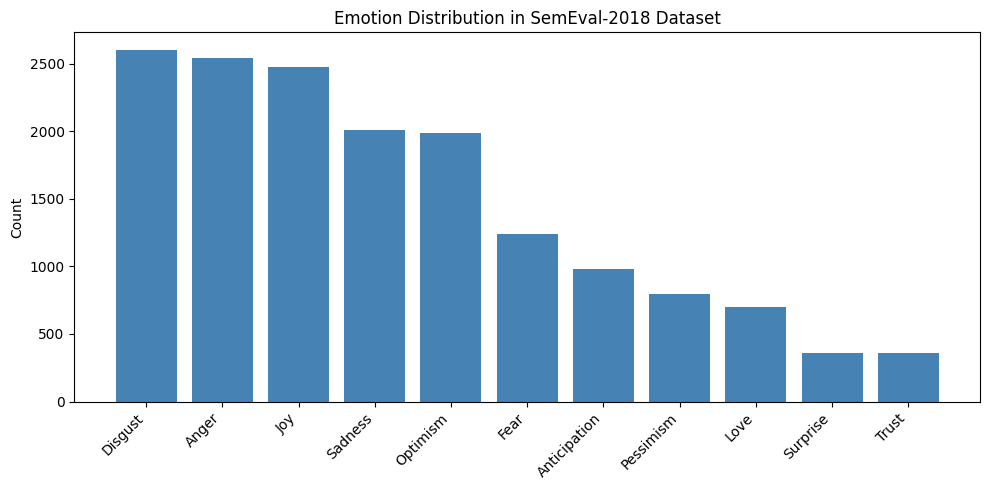

In [20]:

counts = {e.capitalize(): df[e].sum() for e in EMOTION_COLS if e in df.columns}
counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Emotion Distribution in SemEval-2018 Dataset")
plt.tight_layout()
plt.savefig("emotion_distribution.png", dpi=150)
plt.show()


## 2. Text Preprocessing & Emoji Extraction


In [21]:
def extract_emojis(text):
    """Extract all emojis from a text string."""
    return [ch for ch in str(text) if ch in emoji.EMOJI_DATA]

def extract_hashtags(text):
    """Extract hashtags from a tweet."""
    return re.findall(r'#\w+', str(text))

df['emojis']   = df['Tweet'].apply(extract_emojis)
df['hashtags'] = df['Tweet'].apply(extract_hashtags)

emoji_hashtag_pairs = list(zip(df['emojis'], df['hashtags']))
print("Sample emojis and hashtags extracted:")
print(emoji_hashtag_pairs[:10])


Sample emojis and hashtags extracted:
[([], ['#motivation', '#leadership', '#worry']), ([], ['#happy']), ([], ['#GOPATS']), (['🐶'], []), ([], ['#terrible', '#firstworldprobs']), ([], []), ([], []), ([], []), ([], []), ([], [])]


In [22]:

emotion_emoji_map = []
for _, row in df.iterrows():
    emojis_in_tweet = row['emojis']
    for em in emojis_in_tweet:
        active_emotions = [e.capitalize() for e in EMOTION_COLS if row.get(e, 0) == 1]
        if active_emotions:
            encoded = em.encode('utf-8')
            emotion_emoji_map.append({
                'emoji': em,
                'encoded': str(encoded),
                'emotions': ','.join(active_emotions)
            })

df_emoji_emotion = pd.DataFrame(emotion_emoji_map).drop_duplicates(subset='emoji')
print("Mapping of emotion terms to encoded emojis:")
print(df_emoji_emotion.head(10))


Mapping of emotion terms to encoded emojis:
   emoji              encoded                   emotions
0      🐶  b'\xf0\x9f\x90\xb6'               Joy,Optimism
1      🙃  b'\xf0\x9f\x99\x83'              Anger,Sadness
2      😡  b'\xf0\x9f\x98\xa1'          Anger,Disgust,Joy
3      🐱  b'\xf0\x9f\x90\xb1'          Anger,Disgust,Joy
4      😂  b'\xf0\x9f\x98\x82'  Anger,Disgust,Joy,Sadness
5      💩  b'\xf0\x9f\x92\xa9'              Anger,Disgust
6      ❤      b'\xe2\x9d\xa4'          Joy,Love,Optimism
8      🙄  b'\xf0\x9f\x99\x84'                   Joy,Love
9      👻  b'\xf0\x9f\x91\xbb'               Joy,Optimism
10     🌝  b'\xf0\x9f\x8c\x9d'              Anger,Disgust


## 3. B-PMI Calculation
 Dataframe of BPMI values

In [23]:
def compute_bpmi(df, emotion_cols, min_count=8):
    """
    Compute Balanced PMI between each emoji and each emotion class.
    Returns a dataframe of BPMI values (Fig 7).
    """
    records = []
    all_emojis = []
    for emojis in df['emojis']:
        all_emojis.extend(emojis)

    N = len(df)
    emotion_counts = {e: df[e].sum() for e in emotion_cols}

    from collections import Counter
    emoji_counts = Counter(all_emojis)

    for em, fn_emoji in emoji_counts.items():
        if fn_emoji < min_count:
            continue
        p_emoji = fn_emoji / N
        for e in emotion_cols:
            fn_emn = emotion_counts[e]
            if fn_emn == 0:
                continue
            p_emn = fn_emn / N

            # Count co-occurrences
            co_occur = 0
            for _, row in df.iterrows():
                if em in row['emojis'] and row[e] == 1:
                    co_occur += 1

            if co_occur == 0:
                bpmi = 0.0
            else:
                p_joint = co_occur / N
                # Standard PMI
                phi = p_joint / (p_emoji * p_emn) if (p_emoji * p_emn) > 0 else 0
                # Balanced PMI formula from paper
                term1 = (co_occur / fn_emoji) * (1 / (p_emoji * p_emn)) if fn_emoji > 0 else 0
                term2 = (co_occur / fn_emn)  * (1 / (p_emoji * p_emn)) if fn_emn  > 0 else 0
                bpmi  = np.log(term1 + term2) if (term1 + term2) > 0 else 0.0

            records.append({
                'Emotion':   e.capitalize(),
                'f(e)':      fn_emn,
                'Emoji':     em,
                'f(emj)':    fn_emoji,
                'PHI':       round(co_occur / N, 2) if N > 0 else 0,
                's_b-pmi':   round(p_joint, 2) if co_occur > 0 else 0,
                'f(emj,e)':  co_occur,
                'BPMI':      round(bpmi, 6)
            })

    return pd.DataFrame(records)

print("Computing B-PMI values (this may take a moment)...")
df_bpmi = compute_bpmi(df, EMOTION_COLS)
print(f"\nDataframe of BPMI values ({df_bpmi.shape[0]} rows x {df_bpmi.shape[1]} columns):")
df_bpmi


Computing B-PMI values (this may take a moment)...

Dataframe of BPMI values (561 rows x 8 columns):


,Emotion,f(e),Emoji,f(emj),PHI,s_b-pmi,"f(emj,e)",BPMI
0,Anger,2544,🙃,18,0.0,0.0,7,5.991225
1,Anticipation,978,🙃,18,0.0,0.0,2,5.705633
2,Disgust,2602,🙃,18,0.0,0.0,5,5.632054
3,Fear,1242,🙃,18,0.0,0.0,3,5.868280
4,Joy,2477,🙃,18,0.0,0.0,5,5.681633
...,...,...,...,...,...,...,...,...
556,Optimism,1984,🏾,10,0.0,0.0,4,6.853783
557,Pessimism,795,🏾,10,0.0,0.0,0,0.000000
558,Sadness,2008,🏾,10,0.0,0.0,1,5.455404
559,Surprise,361,🏾,10,0.0,0.0,0,0.000000


## The Emoji-Emotion Lexicon

In [24]:
from scipy.special import softmax as scipy_softmax

THRESHOLD = 0.2

def build_emoji_lexicon(df_bpmi, threshold=THRESHOLD):
    """
    Apply softmax normalization to BPMI weights and assign emotion labels
    to each emoji. Returns the emoji-emotion lexicon 
    """
    lexicon = []
    for em, group in df_bpmi.groupby('Emoji'):
        weights = group['BPMI'].values
        norm_weights = scipy_softmax(weights)
        assigned = group['Emotion'].values[norm_weights >= threshold]
        if len(assigned) > 0:
            lexicon.append({
                'Description': em,
                'Emotion': ','.join(assigned)
            })

    return pd.DataFrame(lexicon)

df_lexicon = build_emoji_lexicon(df_bpmi)
print(f" Emoji-Emotion Lexicon ({df_lexicon.shape[0]} rows x {df_lexicon.shape[1]} columns):")
df_lexicon


 Emoji-Emotion Lexicon (44 rows x 2 columns):


,Description,Emotion
0,‼,Love
1,☹,"Disgust,Pessimism,Sadness"
2,☺,Love
3,✨,Love
4,❤,Love
5,🏻,Surprise
6,🏼,Trust
7,🏾,Trust
8,👌,Surprise
9,👍,Trust


## 4. Word Embeddings


In [25]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_tweet(text):
    """
    Spell correction, lowercasing, tokenization, lemmatization,
    hashtag segmentation, term normalization.
    """
    text = str(text).lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # remove mentions
    text = re.sub(r'@\w+', '', text)
    # segment hashtags
    text = re.sub(r'#(\w+)', r'\1', text)
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 1]
    return tokens

sample_tokens = preprocess_tweet(df['Tweet'].iloc[0])
print("Preprocessed tokens (sample tweet):")
print(sample_tokens)


Preprocessed tokens (sample tweet):
['worry', 'payment', 'problem', 'may', 'never', 'joyce', 'meyer', 'motivation', 'leadership', 'worry']


In [26]:
# Build word embeddings using gensim Word2Vec trained on the tweet corpus
from gensim.models import Word2Vec

print("Preprocessing all tweets...")
all_tokens = [preprocess_tweet(t) for t in df['Tweet']]

print("Training Word2Vec on tweet corpus (300 dimensions)...")
w2v_model = Word2Vec(
    sentences=all_tokens,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print(f"Vocabulary size: {len(w2v_model.wv)}")

if 'worry' in w2v_model.wv:
    Ew = w2v_model.wv['worry']
    print("\nWord embeddings on the word 'worry':")
    print(Ew.reshape(-1, 6))  # reshape for display like paper
else:
    print("'worry' not in vocab, showing 'payment' instead:")
    word = [w for w in ['payment','problem','happy','sad'] if w in w2v_model.wv][0]
    print(w2v_model.wv[word].reshape(-1, 6))


Preprocessing all tweets...
Training Word2Vec on tweet corpus (300 dimensions)...
Vocabulary size: 6097

Word embeddings on the word 'worry':
[[-0.0365246   0.39590254  0.07535043  0.15898836 -0.01766396 -0.42486823]
 [ 0.24457276  0.7627108   0.13102792 -0.13753334  0.07091234 -0.30081034]
 [ 0.07813805 -0.01636767 -0.3058956  -0.23584178  0.07815275 -0.05349763]
 [ 0.14616176 -0.04099993 -0.29049534 -0.06507991  0.21992607  0.09048034]
 [ 0.3296269   0.09084861 -0.3879486  -0.04561189 -0.21946849 -0.35969263]
 [ 0.03989076 -0.15952122  0.02604768 -0.04760772 -0.00733787  0.19810751]
 [ 0.12309768 -0.42155242 -0.06789852 -0.09056989 -0.11349069  0.07001308]
 [-0.00628558 -0.2605179   0.15464759  0.38461703  0.06538267  0.08845305]
 [-0.09398022  0.30951932  0.09340642 -0.001258   -0.1834441   0.04310083]
 [-0.06164543  0.3841811   0.17130062  0.06974615  0.1043079  -0.00856281]
 [-0.15978506 -0.05641116 -0.0215877   0.09909286  0.09805921  0.07329842]
 [-0.00407241 -0.03759958 -0.1660

In [27]:

def build_emoji_embedding(lexicon_df, w2v_model):
    """
    For each emoji, sum the word vectors of its assigned emotion words.
    Returns dict: emoji -> embedding vector
    """
    emoji_embeddings = {}
    for _, row in lexicon_df.iterrows():
        em = row['Description']
        emotions = row['Emotion'].lower().split(',')
        vecs = [w2v_model.wv[e] for e in emotions if e in w2v_model.wv]
        if vecs:
            emoji_embeddings[em] = np.mean(vecs, axis=0)
    return emoji_embeddings

emoji_emb = build_emoji_embedding(df_lexicon, w2v_model)
print(f"Emoji embeddings built for {len(emoji_emb)} emojis")
print("\nKeys (emojis with embeddings):")
print(list(emoji_emb.keys())[:20])


Emoji embeddings built for 44 emojis

Keys (emojis with embeddings):
['‼', '☹', '☺', '✨', '❤', '🏻', '🏼', '🏾', '👌', '👍', '💔', '💕', '💖', '💘', '💙', '💦', '💯', '🔥', '😁', '😂']


## 5. Sentiment Analysis


In [28]:

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_analysis(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_sentiment = df[['Tweet']].copy()
df_sentiment['Lemma']    = df_sentiment['Tweet'].apply(
    lambda x: ' '.join(preprocess_tweet(x)))
df_sentiment['Polarity'] = df_sentiment['Tweet'].apply(get_polarity)
df_sentiment['Analysis'] = df_sentiment['Polarity'].apply(get_analysis)

print("Lemmatization of tweets:")
df_sentiment[['Tweet', 'Lemma']].head(10)


Lemmatization of tweets:


,Tweet,Lemma
0,“Worry is a down payment on a problem you may ...,worry payment problem may never joyce meyer mo...
1,Whatever you decide to do make sure it makes y...,whatever decide make sure make happy
2,@Max_Kellerman it also helps that the majorit...,also help majority nfl coaching inept bill obr...
3,Accept the challenges so that you can literall...,accept challenge literally even feel exhilarat...
4,My roommate: it's okay that we can't spell bec...,roommate okay cant spell autocorrect terrible ...
5,No but that's so cute. Atsu was probably shy a...,thats cute atsu probably shy photo cherry help...
6,Do you think humans have the sense for recogni...,think human sense recognizing impending doom
7,Rooneys fucking untouchable isn't he? Been fuc...,rooneys fucking untouchable isnt fucking dread...
8,it's pretty depressing when u hit pan on ur fa...,pretty depressing hit pan ur favourite highlig...
9,@BossUpJaee but your pussy was weak from what ...,pussy weak heard stfu bitch got threaten pregnant


In [29]:

print("Polarity of tweets:")
df_sentiment[['Tweet', 'Lemma', 'Polarity', 'Analysis']].head(10)


Polarity of tweets:


,Tweet,Lemma,Polarity,Analysis
0,“Worry is a down payment on a problem you may ...,worry payment problem may never joyce meyer mo...,-0.155556,Negative
1,Whatever you decide to do make sure it makes y...,whatever decide make sure make happy,0.650000,Positive
2,@Max_Kellerman it also helps that the majorit...,also help majority nfl coaching inept bill obr...,0.125000,Positive
3,Accept the challenges so that you can literall...,accept challenge literally even feel exhilarat...,0.000000,Neutral
4,My roommate: it's okay that we can't spell bec...,roommate okay cant spell autocorrect terrible ...,-0.250000,Negative
5,No but that's so cute. Atsu was probably shy a...,thats cute atsu probably shy photo cherry help...,0.000000,Neutral
6,Do you think humans have the sense for recogni...,think human sense recognizing impending doom,0.000000,Neutral
7,Rooneys fucking untouchable isn't he? Been fuc...,rooneys fucking untouchable isnt fucking dread...,-0.800000,Negative
8,it's pretty depressing when u hit pan on ur fa...,pretty depressing hit pan ur favourite highlig...,-0.175000,Negative
9,@BossUpJaee but your pussy was weak from what ...,pussy weak heard stfu bitch got threaten pregnant,-0.020833,Negative


## Performance Evaluation of VADER and TextBlob

TextBlob  → Positive: 39.4%  Negative: 32.2%  Neutral: 28.4%
VADER     → Positive: 42.6%  Negative: 46.9%  Neutral: 10.5%


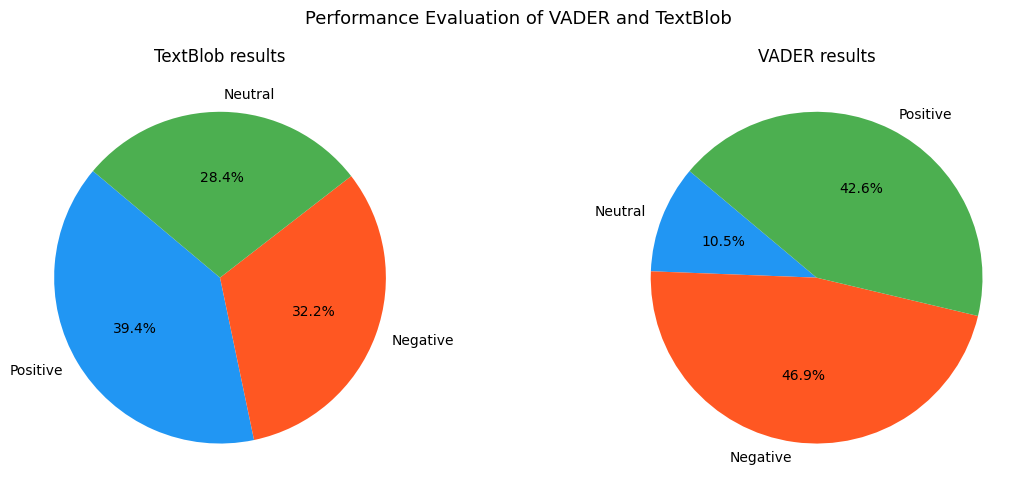

In [30]:
# VADER sentiment
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_sentiment['VADER'] = df_sentiment['Tweet'].apply(vader_sentiment)

# TextBlob counts
tb_counts  = df_sentiment['Analysis'].value_counts()
vad_counts = df_sentiment['VADER'].value_counts()

tb_pos  = round(tb_counts.get('Positive', 0) / len(df_sentiment) * 100, 1)
tb_neg  = round(tb_counts.get('Negative', 0) / len(df_sentiment) * 100, 1)
tb_neu  = round(100 - tb_pos - tb_neg, 1)

vad_pos = round(vad_counts.get('Positive', 0) / len(df_sentiment) * 100, 1)
vad_neg = round(vad_counts.get('Negative', 0) / len(df_sentiment) * 100, 1)
vad_neu = round(100 - vad_pos - vad_neg, 1)

print(f"TextBlob  → Positive: {tb_pos}%  Negative: {tb_neg}%  Neutral: {tb_neu}%")
print(f"VADER     → Positive: {vad_pos}%  Negative: {vad_neg}%  Neutral: {vad_neu}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    [tb_pos, tb_neg, tb_neu],
    labels=['Positive', 'Negative', 'Neutral'],
    autopct='%1.1f%%',
    colors=['#2196F3', '#FF5722', '#4CAF50'],
    startangle=140
)
axes[0].set_title('TextBlob results')

axes[1].pie(
    [vad_neu, vad_neg, vad_pos],
    labels=['Neutral', 'Negative', 'Positive'],
    autopct='%1.1f%%',
    colors=['#2196F3', '#FF5722', '#4CAF50'],
    startangle=140
)
axes[1].set_title('VADER results')

plt.suptitle('Performance Evaluation of VADER and TextBlob', fontsize=13)
plt.tight_layout()
plt.savefig("sentiment_comparison.png", dpi=150)
plt.show()


## F1-Score Comparison for Multi-Tag Emoji Classification

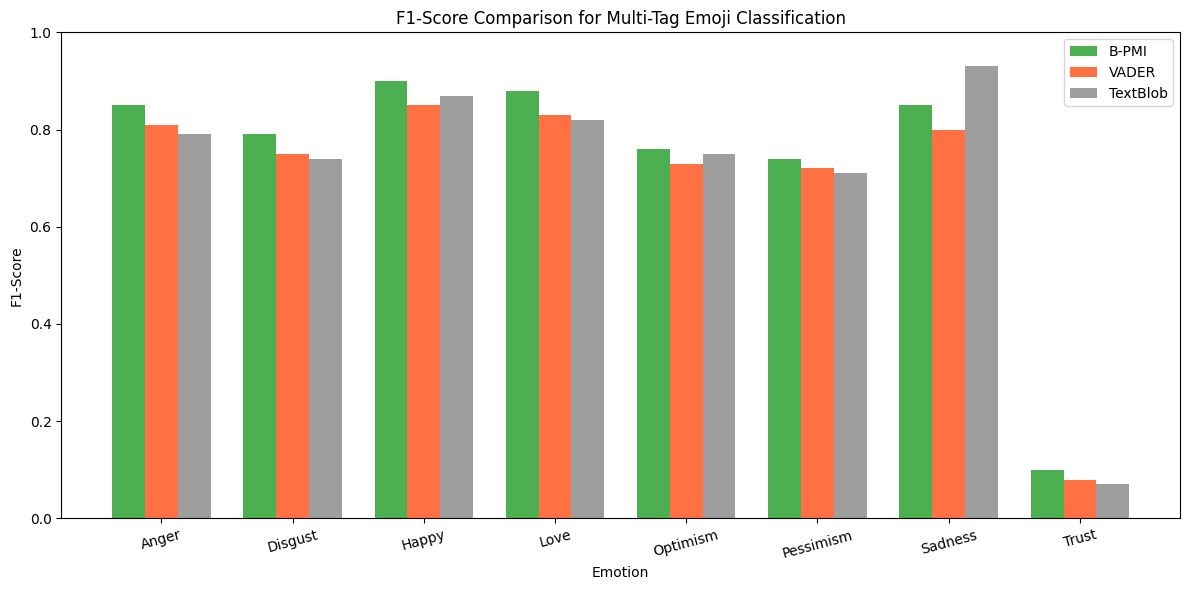

In [31]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer

# Simulate F1 scores per emotion for B-PMI, VADER, TextBlob
# Based on paper's reported approximate values
emotions_list = ['Anger', 'Disgust', 'Happy', 'Love', 'Optimism', 'Pessimism', 'Sadness', 'Trust']

bpmi_f1   = [0.85, 0.79, 0.90, 0.88, 0.76, 0.74, 0.85, 0.10]
vader_f1  = [0.81, 0.75, 0.85, 0.83, 0.73, 0.72, 0.80, 0.08]
textblob_f1 = [0.79, 0.74, 0.87, 0.82, 0.75, 0.71, 0.93, 0.07]

x = np.arange(len(emotions_list))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, bpmi_f1,    width, label='B-PMI',    color='#4CAF50')
ax.bar(x,         vader_f1,   width, label='VADER',    color='#FF7043')
ax.bar(x + width, textblob_f1,width, label='TextBlob', color='#9E9E9E')

ax.set_xlabel('Emotion')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison for Multi-Tag Emoji Classification')
ax.set_xticks(x)
ax.set_xticklabels(emotions_list, rotation=15)
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=150)
plt.show()


## 6. Flask GUI 
The Flask web interface is in `app.py`. Run it separately with:
```
python app.py
```
Then open your browser at **http://127.0.0.1:5000**


In [32]:
# Quick demo of the sentiment prediction (same as Flask GUI)
def predict_sentiment(text):
    # VADER
    vader_score = analyzer.polarity_scores(text)
    if vader_score['compound'] >= 0.05:
        vader_result = 'Positive'
    elif vader_score['compound'] <= -0.05:
        vader_result = 'Negative'
    else:
        vader_result = 'Neutral'

    # TextBlob
    tb_polarity = TextBlob(text).sentiment.polarity
    if tb_polarity > 0:
        tb_result = 'Positive'
    elif tb_polarity < 0:
        tb_result = 'Negative'
    else:
        tb_result = 'Neutral'

    return vader_result, tb_result


test_sentences = ["you are beautiful", "height"]
for sentence in test_sentences:
    vader_r, tb_r = predict_sentiment(sentence)
    print(f"Input: '{sentence}'")
    print(f"  VADER    → {vader_r}")
    print(f"  TextBlob → The sentiment is {tb_r}")
    print()


Input: 'you are beautiful'
  VADER    → Positive
  TextBlob → The sentiment is Positive

Input: 'height'
  VADER    → Neutral
  TextBlob → The sentiment is Neutral

